# Student Performance Analysis
## Exploratory Data Analysis of Factors Influencing Secondary School Student Performance

This notebook presents an exploratory data analysis of the Student Performance dataset from the UCI Machine Learning Repository.  
It was originally developed as part of a university course assignment and is shared here in a cleaned portfolio format.

---

```
Author:   Zeinab Bagheri Fard
Contact:  bagherifard.zeinab@gmail.com
```

In [1]:
%pip install pandas

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import the basic libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset

## Student Performance Dataset

This project analyzes the Student Performance dataset from the UCI Machine Learning Repository.  
The dataset contains demographic, social, and academic variables related to student achievement in secondary education.

**Source:** UCI Machine Learning Repository – Student Performance Dataset

**Description**

The purpose of the dataset is predicting students performance in secondary education (high school).
This data approaches students' achievement in secondary education of **Gabriel Pereira** and **Mousinho da Silveira** Portuguese schools.
This notebook uses the mathematics course dataset (`student-mat.csv`).  
The data dictionary and additional documentation are provided in the original dataset description from UCI.  
The file uses semicolon-separated values.
- The dataset contains 33 features and 395 observations.
- Some **numerical** variables are the student's `age`, `traveltime` duration time between home to school, `studytime` based on weekly hours, `failures` number of past failures (If the value exceeds 4, it is referred as 4.), `absences`, also `G1`first period , `G2` second period grade, and `G3` final grade.
- Some **categorical** variables are **nominal & non-binary**, like `Mjob` or `Fjob`, which are the parent's job, and `reason` to choose the school. Besides, there are some **nominal & binary** variables like  `sex`, `famsize` family size.
- Some **categorical** variables are **ordinal & non-binary** like `Medu` or `Fedu` about parent's education (0 - none,  1 - primary education (4th grade), 2 – 5th to 9th grade, 3 – secondary education or 4 – higher education), `famrel` quality of family relationships (from 1 - very bad to 5 - excellent), and `health` current health status (from 1 - very bad to 5 - very good).


In [3]:
# Pandas built-in function to load the dataset file into DataFrames.
df = pd.read_csv("student-mat.csv")
df.head()

,school;sex;age;address;famsize;Pstatus;Medu;Fedu;Mjob;Fjob;reason;guardian;traveltime;studytime;failures;schoolsup;famsup;paid;activities;nursery;higher;internet;romantic;famrel;freetime;goout;Dalc;Walc;health;absences;G1;G2;G3
0,"GP;""F"";18;""U"";""GT3"";""A"";4;4;""at_home"";""teacher..."
1,"GP;""F"";17;""U"";""GT3"";""T"";1;1;""at_home"";""other"";..."
2,"GP;""F"";15;""U"";""LE3"";""T"";1;1;""at_home"";""other"";..."
3,"GP;""F"";15;""U"";""GT3"";""T"";4;2;""health"";""services..."
4,"GP;""F"";16;""U"";""GT3"";""T"";3;3;""other"";""other"";""h..."


In [4]:
df = pd.read_csv("student-mat.csv", sep=";", true_values =["yes"], false_values=["no"])
df

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,MS,M,20,U,LE3,A,2,2,services,services,...,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,...,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,...,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,...,4,4,1,3,4,5,0,11,12,10


In [5]:
# Total size of the dataset: features and observations
print("Num of features and observations:" , df.shape)

Num of features and observations: (395, 33)


In [6]:
# Variable types
print("Num of features and observations:")
df.dtypes

Num of features and observations:


school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup       bool
famsup          bool
paid            bool
activities      bool
nursery         bool
higher          bool
internet        bool
romantic        bool
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

# 2. Data Preparation
## Assigning Appropriate Data Types

In [7]:
# Nominal categorical variables
df["school"] = df["school"].astype("category")
df["sex"] = df["sex"].astype("category")
df["address"] = df["address"].astype("category")
df["famsize"] = df["famsize"].astype("category")
df["Mjob"] = df["Mjob"].astype("category")
df["Fjob"] = df["Fjob"].astype("category")
df["reason"] = df["reason"].astype("category")
df["guardian"] = df["guardian"].astype("category")

In [8]:
# Ordinal categorical variables
categEducation = list(range(5))
categRelationships = list(range(1, 6))
df["Medu"] = pd.Categorical(df["Medu"], categories=categEducation, ordered=True)
df["Fedu"] = pd.Categorical(df["Fedu"], categories=categEducation, ordered=True)
df["famrel"] = pd.Categorical(df["famrel"], categories=categRelationships, ordered=True)
df["health"] = pd.Categorical(df["health"], categories=categRelationships, ordered=True)
# Check the types
df.dtypes

school        category
sex           category
age              int64
address       category
famsize       category
Pstatus         object
Medu          category
Fedu          category
Mjob          category
Fjob          category
reason        category
guardian      category
traveltime       int64
studytime        int64
failures         int64
schoolsup         bool
famsup            bool
paid              bool
activities        bool
nursery           bool
higher            bool
internet          bool
romantic          bool
famrel        category
freetime         int64
goout            int64
Dalc             int64
Walc             int64
health        category
absences         int64
G1               int64
G2               int64
G3               int64
dtype: object

## Feature Selection and Renaming

In this step, less relevant variables are removed to simplify the analysis and focus on features that are more useful for interpretation.

In [9]:
df.drop(["sex", "age", "address", "famsize", "Pstatus", "guardian", "schoolsup", "famsup", "paid", "activities","nursery", "higher",
         "internet","romantic", "famrel", "freetime", "goout","Dalc", "Walc"], 
        axis=1, inplace=True)
df = df.rename(columns={
                          "Medu":"Mother_Education",
                          "Fedu": "Father_Education",
                          "Mjob":"Mother_Job",
                          "Fjob": "Father_Job",
                          })
df.sample(3)


,school,Mother_Education,Father_Education,Mother_Job,Father_Job,reason,traveltime,studytime,failures,health,absences,G1,G2,G3
365,MS,1,3,at_home,other,course,2,2,0,3,4,10,10,10
75,GP,4,3,teacher,other,home,1,2,0,5,6,9,9,10
42,GP,4,4,services,teacher,course,1,2,0,5,2,19,18,18


In [10]:
df.dtypes

school              category
Mother_Education    category
Father_Education    category
Mother_Job          category
Father_Job          category
reason              category
traveltime             int64
studytime              int64
failures               int64
health              category
absences               int64
G1                     int64
G2                     int64
G3                     int64
dtype: object

## Filtering data

In this section, data **Gabriel Pereira** school would be filtered to be analyzed, the data from **Mousinho da Silveira** woud be eliminated.

In [11]:
df_processed = df[(df["school"]=="GP")]
df_processed.drop("school", axis=1, inplace=True)  #since there is just one school, it is deleted
df_processed.to_csv("./student-mat_processed.csv",
                    index=False) # We do not store the index (row number) because it isn't useful information


C:\Users\Zeynab\AppData\Local\Temp\ipykernel_6772\2454352352.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_processed.drop("school", axis=1, inplace=True)  #since there is just one school, it is deleted


# 3. Exploratory Data Analysis

A cleaned subset of the dataset is saved as `student-mat_processed.csv` for easier downstream analysis.  
This processed dataset contains records from the Gabriel Pereira school and includes 13 features and 349 observations.


In [12]:
# Load the new processed file
data = pd.read_csv("./student-mat_processed.csv")

# Show the first rows
data.head()


,Mother_Education,Father_Education,Mother_Job,Father_Job,reason,traveltime,studytime,failures,health,absences,G1,G2,G3
0,4,4,at_home,teacher,course,2,2,0,3,6,5,6,6
1,1,1,at_home,other,course,1,2,0,3,4,5,5,6
2,1,1,at_home,other,other,1,2,3,3,10,7,8,10
3,4,2,health,services,home,1,3,0,5,2,15,14,15
4,3,3,other,other,home,1,2,0,5,4,6,10,10


In [13]:
data.shape

(349, 13)

## Describe all variables

In [14]:
print("Numerical variables:")
data.describe() 

Numerical variables:


,Mother_Education,Father_Education,traveltime,studytime,failures,health,absences,G1,G2,G3
count,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000
mean,2.802292,2.553009,1.386819,2.063037,0.318052,3.575931,5.965616,10.939828,10.782235,10.489971
std,1.068566,1.080482,0.666910,0.851998,0.734409,1.382607,8.341764,3.319109,3.808434,4.625397
min,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,1.000000,0.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,3.000000,3.000000,1.000000,2.000000,0.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [15]:
print("Categorical variables:")
data.describe(include='object')

Categorical variables:


,Mother_Job,Father_Job,reason
count,349,349,349
unique,5,5,4
top,other,other,course
freq,122,196,124


In [16]:
print("All variables:")
data.describe(include='all')

All variables:


,Mother_Education,Father_Education,Mother_Job,Father_Job,reason,traveltime,studytime,failures,health,absences,G1,G2,G3
count,349.000000,349.000000,349,349,349,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000,349.000000
unique,NaN,NaN,5,5,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,other,other,course,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,122,196,124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.802292,2.553009,NaN,NaN,NaN,1.386819,2.063037,0.318052,3.575931,5.965616,10.939828,10.782235,10.489971
std,1.068566,1.080482,NaN,NaN,NaN,0.666910,0.851998,0.734409,1.382607,8.341764,3.319109,3.808434,4.625397
min,0.000000,0.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,2.000000,2.000000,NaN,NaN,NaN,1.000000,1.000000,0.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,3.000000,3.000000,NaN,NaN,NaN,1.000000,2.000000,0.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,4.000000,3.000000,NaN,NaN,NaN,2.000000,2.000000,0.000000,5.000000,8.000000,13.000000,13.000000,14.000000


## Missing values

In [17]:
# Count missing values per feature
data.isnull().sum()

Mother_Education    0
Father_Education    0
Mother_Job          0
Father_Job          0
reason              0
traveltime          0
studytime           0
failures            0
health              0
absences            0
G1                  0
G2                  0
G3                  0
dtype: int64

## Questions and answers

### Univariate analytical questions:

1. What is the average number of absences among students?


In [18]:
print(f'Average of absence among students: { data["absences"].mean() }')

Average of absence among students: 5.965616045845272


The number of absences in the whole dataset is described as between 0 and 93, while the average of absences among students is 5.96 (it is calculated by adding the whole sum of absences column, then deviding it to the whole numbers=349), so it shows that in total, being absent is not a significant problem in this school. Students do not have a problem being present at the course. 

2. What percentage of students achieved a final grade (G3) equal to or greater than 17?


In [19]:
data_filtered = data[data["G3"] > 15]
perc_G3_Great = (data_filtered.shape[0] / data.shape[0]) * 100
print("The percentage of students achieved a final grade (G3) equal to or greater than 16:", perc_G3_Great)

The percentage of students achieved a final grade (G3) equal to or greater than 16: 10.601719197707736


In this analysis, the percentage of students who achieve a final score greater than 15 is calculated. It involves filtering the column where G3 is greater than or equal to 16. Then, this number is divided by the total number of students, which is 349, and multiplied by 100. The result indicates that the overall final grades may not be good enough.

### Bivariate analytical questions:

1. What is the proportion of students who have a travel time of more than 30 minutes and get a final grade less than 11?

In [20]:
data_filtered = data[ (data["traveltime"]>=3) & (data["G3"]<11)]
perc_travel = (data_filtered.shape[0] / data.shape[0]) * 100
print("The percentage of students who have a travel time of more than 30 minutes and get a final grade less than 11:", perc_travel)
data_filtered.groupby(by=["traveltime", "G3"]).size()

The percentage of students who have a travel time of more than 30 minutes and get a final grade less than 11: 3.7249283667621778


traveltime  G3
3           0     3
            8     1
            10    4
4           0     1
            7     1
            9     1
            10    2
dtype: int64

Here the fileteres columns are traveltime and G3, it is calculated by filtering the students who travle more than 30 minutes ( 3 indicates 30 min. to 1 hour, and 4 indicates more than 1 hour),  resulting in 22 students. Then, filtering for G3 score less than 11 , which shows 13 students, and calculating this percentage. It means that traveltime, is not a big factor contributing to failing grades.

2. How does student health correlate with the average of past failures?


In [21]:
#data_filtered = data[ (data["traveltime"]>=3) & (data["G3"]<11)]
data_filtered.groupby(by=["health", "failures"]).size()

health  failures
2       0           1
        2           1
3       0           2
4       0           3
        3           1
5       0           2
        1           1
        3           2
dtype: int64

This code groups the data by student health status and the number of past failures, calculating the number of past failures for each health status. It shows how student health affect past failures. This analysis can guide interventions to support student well-being and academic success. As shown here, the most common number of failures is 0 across different health statuses.

### Bivariate or multivariate analytical questions: data visualization

1. Does the level of parental education (Mother_Education and Father_Education) affect students past failures?

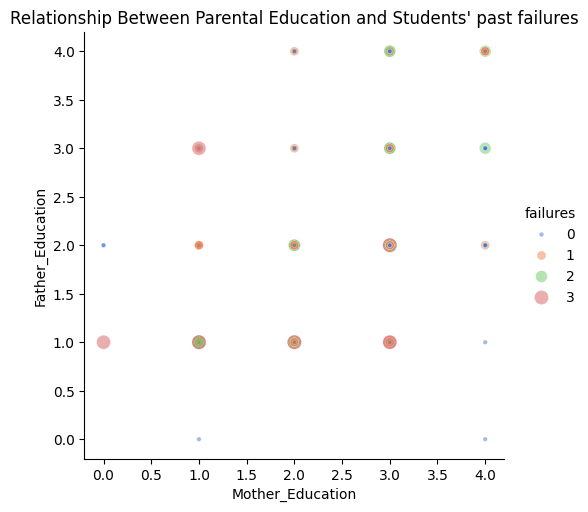

In [22]:
sns.relplot(data=data, x="Mother_Education", y="Father_Education", hue="failures" ,
           size="failures",
            sizes=(10, 100), alpha=.5, palette="muted"
               )
plt.title("Relationship Between Parental Education and Students' past failures")

#plt.legend(title="G3")
plt.show()

The above code displays the visualization of the connection between parents' education and students' past failures. Based on this, students whose parents have an education level greater than 2 (indicating above 5th grade) typically experience fewer failures.besides, those whose parents have an education level of 4 (indicating higher education) tend to have fewer failures. 

2. What is the average G3 based on studytime and health?

In [23]:
#data_filtered = data[ (data["failures"]==0)]
data_filtered =  data.groupby(by=["studytime" , "health"])["G3"].mean()
data_filtered 
# Unwrap the pivot table into a regular pandas dataframe
de_data_filtered = data_filtered.unstack()
de_data_filtered

health,1,2,3,4,5
studytime,,,,,
1,13.111111,11.125000,10.066667,9.142857,10.302326
2,11.600000,8.521739,9.540541,9.379310,10.806452
3,14.000000,13.666667,10.375000,12.428571,10.368421
4,12.500000,11.333333,10.900000,9.500000,12.166667


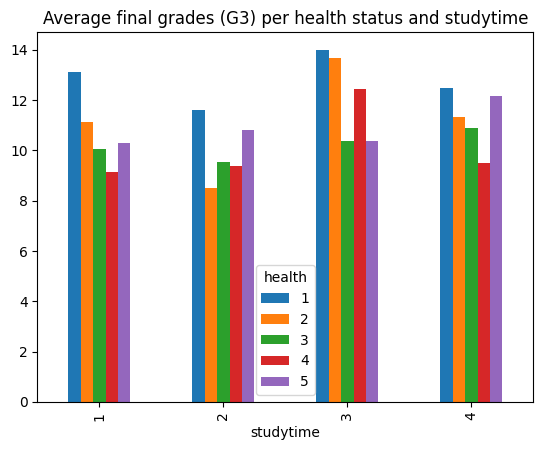

In [24]:
de_data_filtered.plot.bar(stacked=False)
plt.title("Average final grades (G3) per health status and studytime")
plt.show()

In this code, the dataframe shows the average of G3 depending on different values of studytime and health. In fact, the results are not like as it was expected, since when students study more and have a better health statues, the average is not higher. So as it is shown, there is not meaningful connection between these 3 variables.

3. What is the relationship between travel time and absences?

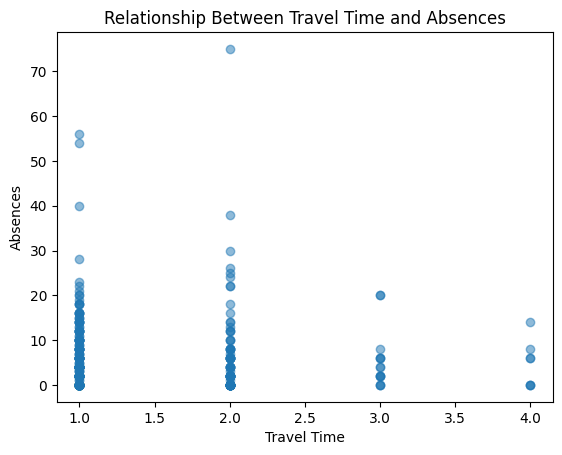

In [25]:
# Create a scatter plot
plt.scatter(data['traveltime'], data['absences'], alpha=0.5)
plt.title('Relationship Between Travel Time and Absences')
plt.xlabel('Travel Time')
plt.ylabel('Absences')
plt.show()


The above graph shows a slight absence of students on long trips. It shows that being far away does not affect being absent from the course. However, it is out of expect to see more than 50 absences in less than 30 minutes of travel time (traveltime 1: less than 15 min,and 2: 15 to 30 min)

4. How does traveltime relate to studytime?

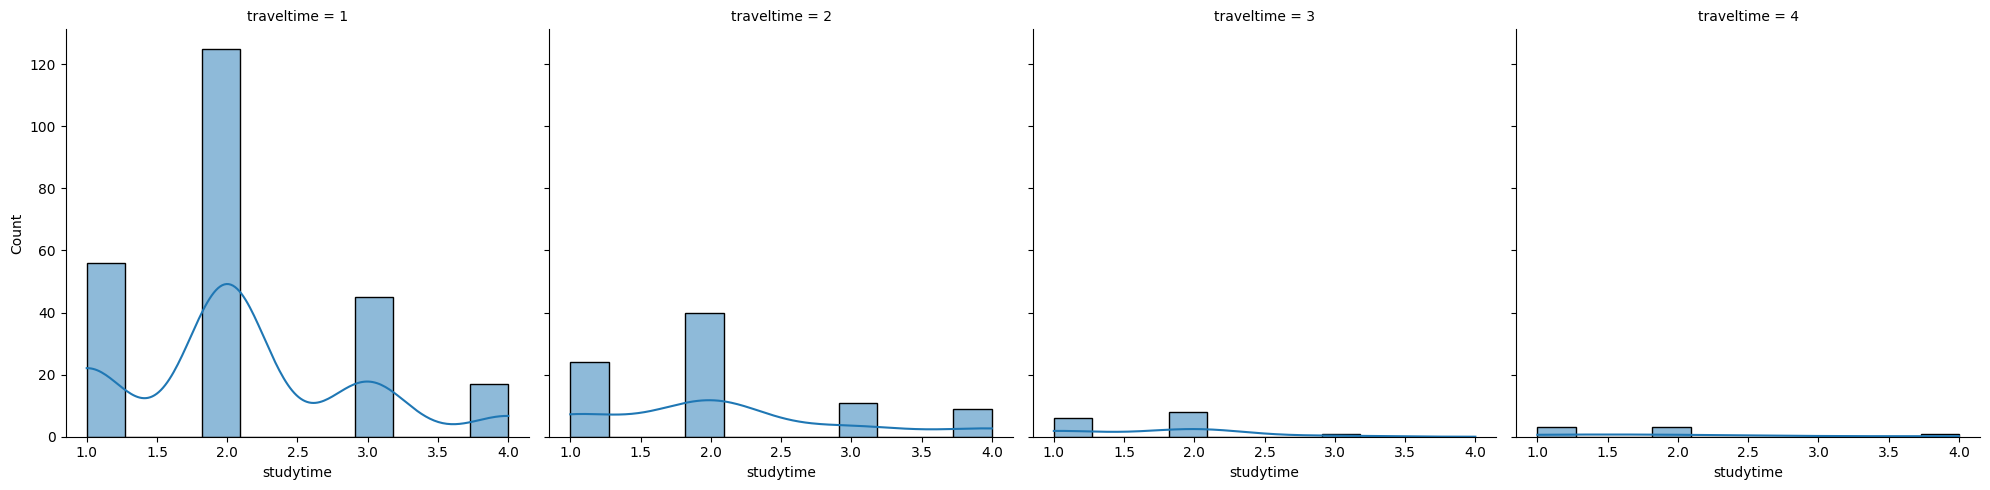

In [26]:
sns.displot(data, x="studytime", col="traveltime", kde=True)
plt.show()

In the above section, the sudytime is shown based on different traveltime. As illustrated, the studytime decreases when traveltime increases, which is expected. This means that when students travel more between school and home, they can dedicate less time to studying.

### Correlation analysis

Correlation analysis between final grades (G3) and second period grade (G2):

In [27]:
numerical_data = data[['G3', 'G2']]
correlations = numerical_data.corr(method="pearson", numeric_only=True)
correlations

,G3,G2
G3,1.000000,0.902783
G2,0.902783,1.000000


As it is shown, in regards of strenght, there is a large correlation (0.902783) between these two variables, and about direction, it is positive. So increaing G2, leads to increasing G3. Overal, there is a large correlation between these grades.

# Conclusion

This notebook explored the Student Performance dataset through data cleaning, type correction, feature selection, and exploratory analysis.  
The project demonstrates basic data analysis workflow skills in Python using pandas and visualization libraries.